In [2]:
import numpy as np

import venti

In [3]:
print(dir(venti))

['__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_version', 'models']


In [4]:
from venti.models import load_itrf, plate_motion

In [5]:
# Your GPS data
longitude = np.array([-120.0, -115.0, -110.0, -105.0, -100.0])
latitude = np.array([35.0, 40.0, 45.0, 40.0, 35.0])
velocity_east = np.array([2.1, 1.8, 1.5, 1.2, 0.9])  # mm/year
velocity_north = np.array([0.5, 0.8, 1.1, 1.4, 1.7])  # mm/year
sigma_east = np.array([0.1, 0.15, 0.12, 0.11, 0.13])  # mm/year
sigma_north = np.array([0.12, 0.14, 0.11, 0.13, 0.15])  # mm/year

# Calculate Euler pole
euler_lon, euler_lat, omega, stats = plate_motion.calculate_euler_pole(
    longitude, latitude, velocity_east, velocity_north,
    sigma_east, sigma_north
)

print(f"Euler Pole: {euler_lon:.2f}°, {euler_lat:.2f}°")
print(f"Angular velocity: {omega:.3f} °/Myr")
print(f"RMS: {stats['rms']:.2f} mm/year")


Euler Pole: -136.47°, 57.02°
Angular velocity: 0.039 °/Myr
RMS: 0.59 mm/year


In [6]:
max_sigma, min_sigma, azimuth, sigma_omega = plate_motion.get_euler_pole_uncertainty(
            euler_lon, euler_lat, omega, stats['parameter_covariance'])

In [7]:
# Display results
print("\nEULER POLE RESULTS:")
print(f"  Longitude: {euler_lon:.3f}° ± {max_sigma:.3f}°")
print(f"  Latitude:  {euler_lat:.3f}° ± {min_sigma:.3f}°")
print(f"  Rotation:  {omega:.4f} ± {sigma_omega:.4f} °/Myr")

print("\nUNCERTAINTY ELLIPSE:")
print(f"  Semi-major axis: {max_sigma:.3f}°")
print(f"  Semi-minor axis: {min_sigma:.3f}°")
print(f"  Ellipse azimuth: {azimuth:.1f}°")
print(f"  Ellipticity: {max_sigma/min_sigma:.2f}")

print("\nFIT QUALITY STATISTICS:")
print(f"  RMS:              {stats['rms']:.2f} mm/year")
print(f"  Weighted RMS:     {stats['wrms']:.2f}")
print(f"  Chi-squared:      {stats['chi_squared']:.2f}")
print(f"  Reduced chi-sq:   {stats['reduced_chi_squared']:.2f}")
print(f"  Degrees of freedom: {stats['degrees_of_freedom']}")

print("\nINTERPRETATION:")
if stats['reduced_chi_squared'] < 1.5:
    print(f"  Good fit: reduced χ² = {stats['reduced_chi_squared']:.2f} < 1.5")
elif stats['reduced_chi_squared'] < 3.0:
    print(f"  Acceptable fit: reduced χ² = {stats['reduced_chi_squared']:.2f}")
else:
    print(f"  Poor fit: reduced χ² = {stats['reduced_chi_squared']:.2f} > 3.0")

if max_sigma < 5.0:
    print(f"  Good position uncertainty: {max_sigma:.2f}° < 5°")
elif max_sigma < 10.0:
    print(f"  Moderate position uncertainty: {max_sigma:.2f}°")
else:
    print(f"  Large position uncertainty: {max_sigma:.2f}° > 10°")

if sigma_omega / omega < 0.1:
    print(f"  Good rotation rate uncertainty: {sigma_omega/omega:.1%} < 10%")
elif sigma_omega / omega < 0.2:
    print(f"  Moderate rotation rate uncertainty: {sigma_omega/omega:.1%}")
else:
    print(f"  Large rotation rate uncertainty: {sigma_omega/omega:.1%} > 20%")


EULER POLE RESULTS:
  Longitude: -136.471° ± 2.768°
  Latitude:  57.016° ± 0.742°
  Rotation:  0.0390 ± 0.0040 °/Myr

UNCERTAINTY ELLIPSE:
  Semi-major axis: 2.768°
  Semi-minor axis: 0.742°
  Ellipse azimuth: -36.1°
  Ellipticity: 3.73

FIT QUALITY STATISTICS:
  RMS:              0.59 mm/year
  Weighted RMS:     0.41
  Chi-squared:      110.80
  Reduced chi-sq:   3.98
  Degrees of freedom: 7

INTERPRETATION:
  Poor fit: reduced χ² = 3.98 > 3.0
  Good position uncertainty: 2.77° < 5°
  Moderate rotation rate uncertainty: 10.1%


In [8]:
modeled_vel = plate_motion.model_velocities_from_euler_pole(longitude, latitude, -107.2, 50.8, 0.65)
modeled_vel

array([[ 20.54729342, -10.1207296 ],
       [ 14.0448572 ,  -6.19797774],
       [  7.57972192,  -2.23026388],
       [ 13.79587853,   1.75312812],
       [ 20.10476875,   5.72544513]])

In [9]:
modeled_vel, uncertainties = plate_motion.model_velocities_from_euler_pole(
    longitude, latitude, euler_lon, euler_lat, omega,
    euler_covariance=stats['parameter_covariance']  # From calculate_euler_pole()
)
modeled_vel, uncertainties

(array([[1.6919189 , 0.66871286],
        [1.38586585, 0.86304367],
        [1.08976059, 1.05068874],
        [1.50316098, 1.23094777],
        [1.90039455, 1.40192818]]),
 array([[0.06377453, 0.08307369],
        [0.05391554, 0.06363358],
        [0.07385925, 0.05751117],
        [0.05382035, 0.06856027],
        [0.0643157 , 0.0904695 ]]))

In [10]:
itrf14_pmm = load_itrf.load_itrf_pmm(date=2014)
itrf20_pmm = load_itrf.load_itrf_pmm(date=2020)

In [12]:
import pandas as pd

itrf14_gps = pd.read_csv(load_itrf.ITRF14_DATA)
itrf20_gps = pd.read_csv(load_itrf.ITRF20_DATA)

In [13]:
pacific_data = itrf14_gps[itrf14_gps['Plate'] == 'Pacific']

# Calculate Euler pole
longitude = pacific_data['Longitude_deg'].values
latitude = pacific_data['Latitude_deg'].values
ve = pacific_data['Ve_mm_yr'].values
vn = pacific_data['Vn_mm_yr'].values
se = pacific_data['Se_mm_yr'].values
sn = pacific_data['Sn_mm_yr'].values

euler_lon, euler_lat, omega, stats = plate_motion.calculate_euler_pole(
    longitude, latitude, ve, vn, se, sn, correlation_coefficient=0.35,
)

# Calculate uncertainties
max_sigma, min_sigma, azimuth, sigma_omega = plate_motion.get_euler_pole_uncertainty(
    euler_lon, euler_lat, omega, stats['parameter_covariance']
)

print("\nCalculated Pacific Plate Euler Pole:")
print(f"  Longitude: {euler_lon:.3f}°")
print(f"  Latitude:  {euler_lat:.3f}°")
print(f"  Angular velocity: {omega:.4f} °/Myr")
print(f"  RMS: {stats['rms']:.2f} mm/year")

np.rad2deg(stats['rotation_rates_rad_per_year'])*1e6


Calculated Pacific Plate Euler Pole:
  Longitude: 111.197°
  Latitude:  -62.524°
  Angular velocity: 0.6796 °/Myr
  RMS: 0.52 mm/year


array([-0.11336805,  0.29232019, -0.60291383])

In [14]:
itrf14_pmm[itrf14_pmm.name == 'Pacific Plate']

,plate,name,omega_x,omega_y,omega_z
8,PCFC,Pacific Plate,-0.1135,0.2907,-0.6025


In [15]:
pacific_data

,CODE,DOMES_Number,Site_Name,Plate,Technique,Longitude_deg,Latitude_deg,Ve_mm_yr,Vn_mm_yr,Se_mm_yr,Sn_mm_yr,Re_mm_yr,Rn_mm_yr
246,POHN,51601M001,Pohnpei,Pacific,P,158.210,6.960,-70.04,25.43,0.012,0.010,0.606,-0.065
247,NAUR,50701M001,Nauru,Pacific,P,166.926,-0.552,-66.96,29.74,0.017,0.015,0.081,-1.072
248,KWJ1,50506M001,Kwajalein atoll,Pacific,PR,167.730,8.722,-69.05,29.60,0.020,0.016,-0.140,-0.659
249,MAJU,51501M001,Majuro,Pacific,P,171.365,7.119,-68.69,30.36,0.029,0.024,0.004,-0.259
250,KIRI,50305M001,Betio island - k,Pacific,P,172.923,1.355,-67.83,31.17,0.010,0.008,0.389,-0.611
251,CHTI,50242M001,Chatham island n,Pacific,D,183.383,-43.735,-40.92,32.72,0.008,0.008,-0.258,0.279
252,CHAT,50207M001,Chatham island,Pacific,DP,183.434,-43.956,-40.72,32.97,0.007,0.006,-0.271,0.038
253,CKIS,50213M003,Rarotonga,Pacific,P,200.199,-21.201,-62.85,35.16,0.008,0.007,0.545,-0.442
254,KOK1,49896S001,Kokole point,Pacific,P,200.242,21.983,-62.30,35.43,0.013,0.011,-0.162,-0.712
255,KOKB,40424M004,Kauai,Pacific,DPR,200.335,22.126,-62.21,34.62,0.007,0.006,-0.185,0.110


In [16]:
pacific_data = itrf20_gps[itrf20_gps['Plate'] == 'Pacific']

# Calculate Euler pole
longitude = pacific_data['Longitude_deg'].values
latitude = pacific_data['Latitude_deg'].values
ve = pacific_data['Ve_mm_yr'].values
vn = pacific_data['Vn_mm_yr'].values
se = pacific_data['Se_mm_yr'].values
sn = pacific_data['Sn_mm_yr'].values

euler_lon, euler_lat, omega, stats = plate_motion.calculate_euler_pole(
    longitude, latitude, ve, vn, se, sn, correlation_coefficient=0,
)

# Calculate uncertainties
max_sigma, min_sigma, azimuth, sigma_omega = plate_motion.get_euler_pole_uncertainty(
    euler_lon, euler_lat, omega, stats['parameter_covariance']
)

n_sites = len(longitude)

print("\nDataset Summary:")
print(f"  Number of GPS stations: {n_sites}")
print(f"  Longitude range: {longitude.min():.1f}° to {longitude.max():.1f}°")
print(f"  Latitude range: {latitude.min():.1f}° to {latitude.max():.1f}°")
print(f"  East velocity range: {ve.min():.1f} to {ve.max():.1f} mm/year")
print(f"  North velocity range: {vn.min():.1f} to {vn.max():.1f} mm/year")

# Euler Pole Results
print("\nCalculated Euler Pole Parameters:")
print(f"  Longitude: {euler_lon:.3f}° ± {max_sigma:.3f}°")
print(f"  Latitude:  {euler_lat:.3f}° ± {min_sigma:.3f}°")
print(f"  Angular velocity: {omega:.4f} ± {sigma_omega:.4f} °/Myr")
print(f"  Uncertainty ellipse azimuth: {azimuth:.1f}°")

# Fit Quality
print("\nModel Fit Quality:")
print(f"  RMS residual: {stats['rms']:.2f} mm/year")
print(f"  Weighted RMS: {stats['wrms']:.2f}")
print(f"  Chi-squared: {stats['chi_squared']:.1f}")
print(f"  Reduced chi-squared: {stats['reduced_chi_squared']:.2f}")
print(f"  Degrees of freedom: {stats['degrees_of_freedom']}")

# Rotation rate components
wx, wy, wz = stats['rotation_rates_rad_per_year']
print("\nRotation Rate Components (rad/year):")
print(f"  ωx = {wx:.3e}")
print(f"  ωy = {wy:.3e}")
print(f"  ωz = {wz:.3e}")
print(f"  |ω| = {np.sqrt(wx**2 + wy**2 + wz**2):.3e}")

# Convert to deg/Myr for prediction
wxyz_deg_myr = np.rad2deg(np.array([wx, wy, wz])) * 1e6
print("\nRotation Rate Components (deg/Myr):")
print(f"  ωx = {wxyz_deg_myr[0]:.6f}")
print(f"  ωy = {wxyz_deg_myr[1]:.6f}")
print(f"  ωz = {wxyz_deg_myr[2]:.6f}")


Dataset Summary:
  Number of GPS stations: 20
  Longitude range: 154.0° to 225.0°
  Latitude range: -44.0° to 24.3°
  East velocity range: -71.6 to -40.7 mm/year
  North velocity range: 23.7 to 35.4 mm/year

Calculated Euler Pole Parameters:
  Longitude: 111.374° ± 0.023°
  Latitude:  -62.590° ± 0.012°
  Angular velocity: 0.6779 ± 0.0002 °/Myr
  Uncertainty ellipse azimuth: 5.9°

Model Fit Quality:
  RMS residual: 0.53 mm/year
  Weighted RMS: 0.22
  Chi-squared: 401.7
  Reduced chi-squared: 3.29
  Degrees of freedom: 37

Rotation Rate Components (rad/year):
  ωx = -1.985e-09
  ωy = 5.072e-09
  ωz = -1.050e-08
  |ω| = 1.183e-08

Rotation Rate Components (deg/Myr):
  ωx = -0.113729
  ωy = 0.290594
  ωz = -0.601749


In [17]:
itrf20_pmm[itrf20_pmm.name == 'Pacific Plate']

,plate,name,omega_x,omega_y,omega_z
10,PCFC,Pacific Plate,-0.1122,0.2836,-0.5984


In [18]:
(np.rad2deg(-0.404 * np.pi / 648000000)*1e6,
np.rad2deg(1.021 * np.pi / 648000000)*1e6,
np.rad2deg(-2.154 * np.pi / 648000000)*1e6)

(np.float64(-0.11222222222222224),
 np.float64(0.28361111111111115),
 np.float64(-0.5983333333333334))

In [19]:
# Use your model_plate_velocities function
predicted_velocities, velocity_uncertainties = plate_motion.model_plate_velocities(
    longitude, latitude,
    wxyz_deg_myr[0], wxyz_deg_myr[1], wxyz_deg_myr[2],
    rotation_covariance=stats['parameter_covariance']
)

ve_pred = predicted_velocities[:, 0]
vn_pred = predicted_velocities[:, 1]
se_pred = velocity_uncertainties[:, 0]
sn_pred = velocity_uncertainties[:, 1]

# Calculate residuals
residual_ve = ve - ve_pred
residual_vn = vn - vn_pred
residual_total = np.sqrt(residual_ve**2 + residual_vn**2)

# Validation statistics
rms_total = np.sqrt(np.mean(residual_total**2))
rms_east = np.sqrt(np.mean(residual_ve**2))
rms_north = np.sqrt(np.mean(residual_vn**2))

print("Validation Statistics:")
print(f"  RMS Total: {rms_total:.3f} mm/year")
print(f"  RMS East:  {rms_east:.3f} mm/year")
print(f"  RMS North: {rms_north:.3f} mm/year")

Validation Statistics:
  RMS Total: 0.527 mm/year
  RMS East:  0.412 mm/year
  RMS North: 0.329 mm/year


In [20]:
comparison_df = pd.DataFrame({
    'Station': pacific_data['CODE'].values,
    'Lon': longitude,
    'Lat': latitude,
    'Ve_obs': ve,
    'Vn_obs': vn,
    'Ve_pred': ve_pred,
    'Vn_pred': vn_pred,
    'Se_obs': se,
    'Sn_obs': sn,
    'Se_pred': se_pred,
    'Sn_pred': sn_pred,
    'Res_Ve': residual_ve,
    'Res_Vn': residual_vn,
    'Res_Total': residual_total
})
comparison_df

,Station,Lon,Lat,Ve_obs,Vn_obs,Ve_pred,Vn_pred,Se_obs,Sn_obs,Se_pred,Sn_pred,Res_Ve,Res_Vn,Res_Total
0,KWJ1,167.730,8.722,-69.06,29.50,-69.116014,28.917044,0.258,0.197,0.018664,0.019942,0.056014,0.582956,0.585641
1,HILO,204.947,19.719,-62.59,35.38,-62.356436,34.657190,0.090,0.080,0.019880,0.016429,-0.233564,0.722810,0.759609
2,LHUE,200.661,21.985,-61.71,34.47,-62.305244,34.718950,0.175,0.164,0.020277,0.016033,0.595244,-0.248950,0.645207
3,MAUI,203.743,20.707,-62.05,34.59,-62.180836,34.693714,0.028,0.025,0.020042,0.016296,0.130836,-0.103714,0.166957
4,KOK1,200.242,21.983,-62.18,35.36,-62.400590,34.714866,0.808,0.673,0.020281,0.016006,0.220590,0.645134,0.681805
5,UPO1,204.116,20.246,-62.65,34.79,-62.301425,34.684246,0.846,0.713,0.019968,0.016336,-0.348575,0.105754,0.364264
6,CKIS,200.199,-21.201,-62.62,34.95,-62.224040,34.715428,0.067,0.058,0.020612,0.016004,-0.395960,0.234572,0.460227
7,CHAT,183.434,-43.956,-40.66,32.94,-40.910632,32.995668,0.043,0.048,0.024828,0.016734,0.250632,-0.055668,0.256740
8,MCIL,153.979,24.290,-71.63,23.67,-71.544273,23.502284,0.057,0.057,0.019637,0.023391,-0.085727,0.167716,0.188355
9,POHN,158.210,6.960,-70.19,24.89,-69.356555,25.336651,0.328,0.275,0.018555,0.022336,-0.833445,-0.446651,0.945583


Creating validation plots...


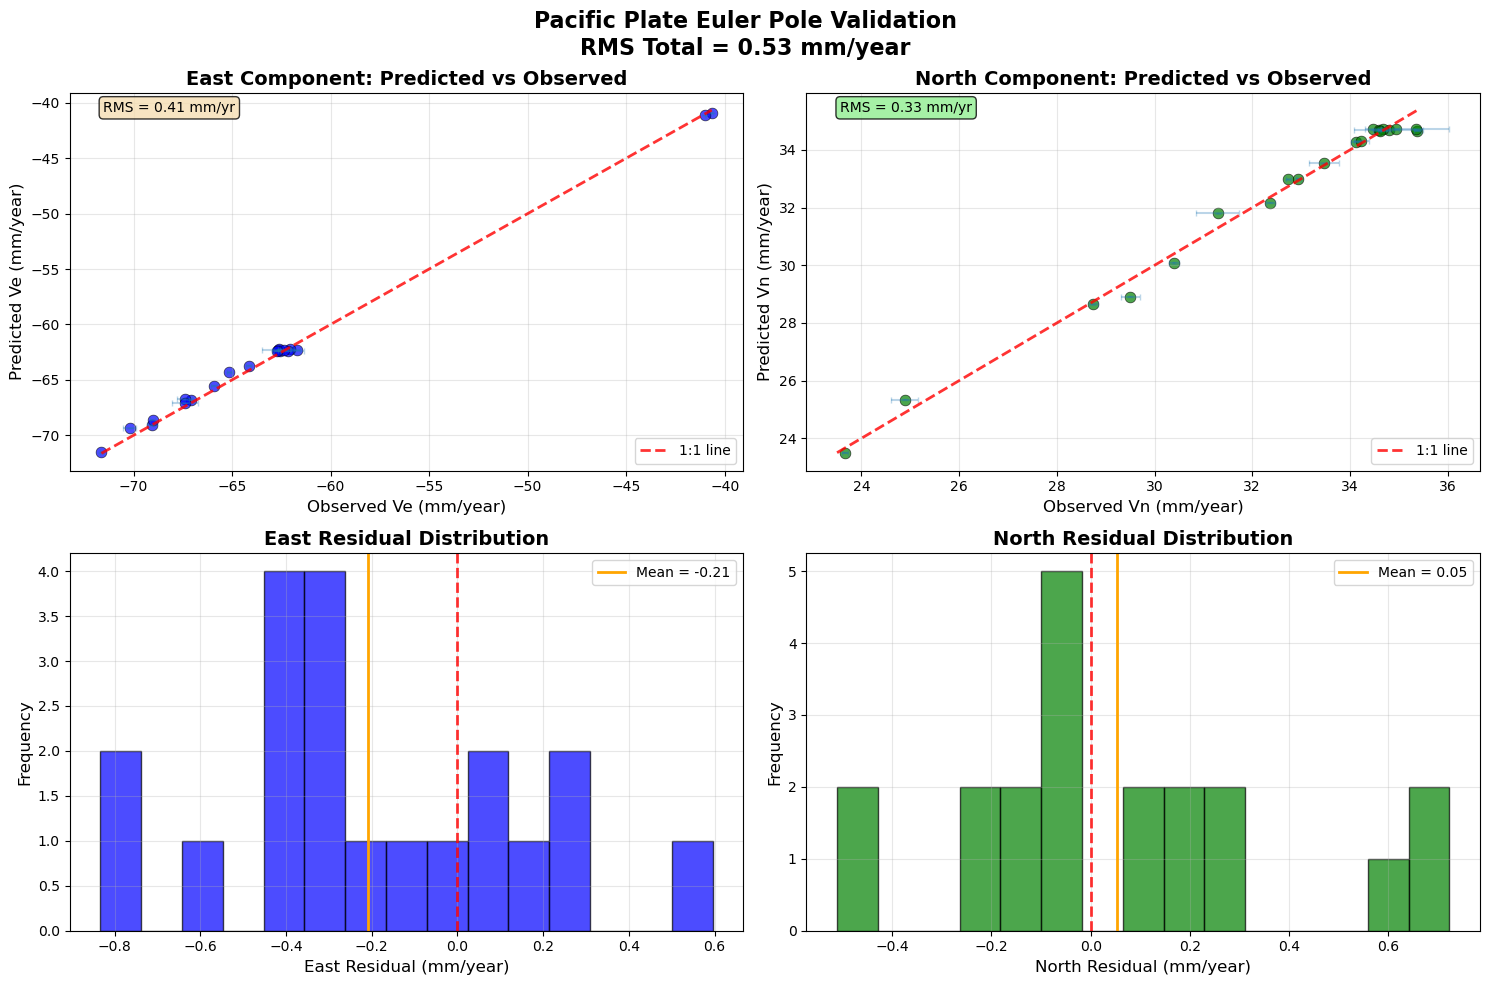

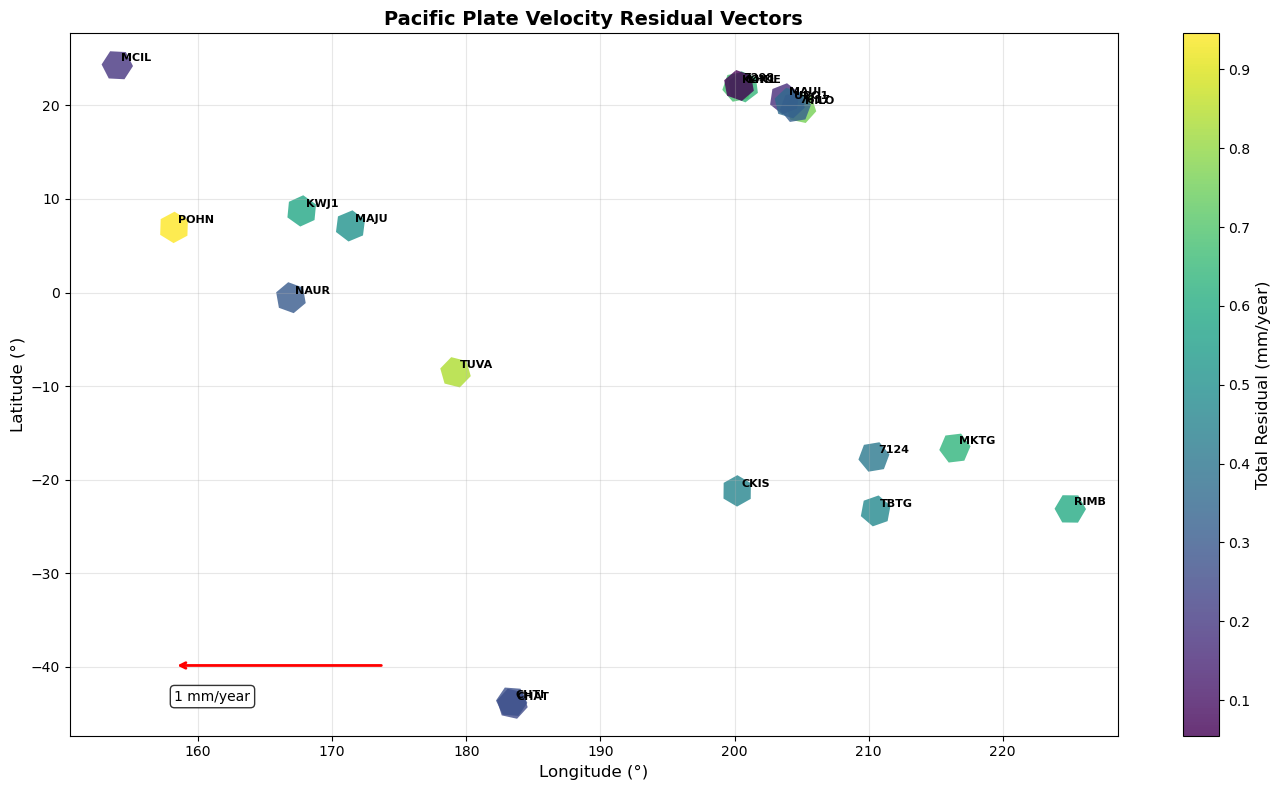

In [22]:
# Quick plotting function for your Pacific plate results

import matplotlib.pyplot as plt
import numpy as np


def plot_pacific_results():
    """Plot your Pacific plate analysis results."""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Predicted vs Observed East velocities
    ax1.scatter(ve, ve_pred, alpha=0.7, s=60, c='blue', edgecolor='black', linewidth=0.5)
    ax1.errorbar(ve, ve_pred, xerr=se, yerr=se_pred, fmt='none', alpha=0.3, capsize=2)

    # 1:1 line
    min_val = min(ve.min(), ve_pred.min())
    max_val = max(ve.max(), ve_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='1:1 line')

    ax1.set_xlabel('Observed Ve (mm/year)', fontsize=12)
    ax1.set_ylabel('Predicted Ve (mm/year)', fontsize=12)
    ax1.set_title('East Component: Predicted vs Observed', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Add RMS text
    ax1.text(0.05, 0.95, f'RMS = {rms_east:.2f} mm/yr', transform=ax1.transAxes,
             bbox={"boxstyle": 'round', "facecolor": 'wheat', "alpha": 0.8}, fontsize=10)

    # 2. Predicted vs Observed North velocities
    ax2.scatter(vn, vn_pred, alpha=0.7, s=60, c='green', edgecolor='black', linewidth=0.5)
    ax2.errorbar(vn, vn_pred, xerr=sn, yerr=sn_pred, fmt='none', alpha=0.3, capsize=2)

    min_val = min(vn.min(), vn_pred.min())
    max_val = max(vn.max(), vn_pred.max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='1:1 line')

    ax2.set_xlabel('Observed Vn (mm/year)', fontsize=12)
    ax2.set_ylabel('Predicted Vn (mm/year)', fontsize=12)
    ax2.set_title('North Component: Predicted vs Observed', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax2.text(0.05, 0.95, f'RMS = {rms_north:.2f} mm/yr', transform=ax2.transAxes,
             bbox={"boxstyle": 'round', "facecolor": 'lightgreen', "alpha": 0.8}, fontsize=10)

    # 3. Residual histogram East
    ax3.hist(residual_ve, bins=15, alpha=0.7, color='blue', edgecolor='black')
    ax3.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax3.axvline(np.mean(residual_ve), color='orange', linestyle='-', linewidth=2,
                label=f'Mean = {np.mean(residual_ve):.2f}')
    ax3.set_xlabel('East Residual (mm/year)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('East Residual Distribution', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Residual histogram North
    ax4.hist(residual_vn, bins=15, alpha=0.7, color='green', edgecolor='black')
    ax4.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax4.axvline(np.mean(residual_vn), color='orange', linestyle='-', linewidth=2,
                label=f'Mean = {np.mean(residual_vn):.2f}')
    ax4.set_xlabel('North Residual (mm/year)', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title('North Residual Distribution', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'Pacific Plate Euler Pole Validation\nRMS Total = {rms_total:.2f} mm/year',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_residual_map():
    """Plot residual vectors on a map."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))

    # Plot residual vectors (scaled for visibility)
    scale = 0.2
    colors = residual_total

    quiver = ax.quiver(longitude, latitude,
                      residual_ve * scale, residual_vn * scale,
                      colors, scale_units='xy', scale=10, alpha=0.8,
                      cmap='viridis', width=0.03)

    # Add station labels
    for i, station in enumerate(pacific_data['CODE'].values):
        ax.annotate(station, (longitude[i], latitude[i]),
                   xytext=(3, 3), textcoords='offset points',
                   fontsize=8, fontweight='bold')

    ax.set_xlabel('Longitude (°)', fontsize=12)
    ax.set_ylabel('Latitude (°)', fontsize=12)
    ax.set_title('Pacific Plate Velocity Residual Vectors', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Colorbar
    cbar = plt.colorbar(quiver, ax=ax)
    cbar.set_label('Total Residual (mm/year)', fontsize=12)

    # Add scale arrow
    ax.annotate('', xy=(0.1, 0.1), xytext=(0.1 + 1*scale, 0.1),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops={"arrowstyle": '->', "lw": 2, "color": 'red'})
    ax.text(0.1, 0.05, '1 mm/year', transform=ax.transAxes, fontsize=10,
            bbox={"boxstyle": 'round', "facecolor": 'white', "alpha": 0.8})

    plt.tight_layout()
    plt.show()


# Run the plots
print("Creating validation plots...")
plot_pacific_results()
plot_residual_map()
